<a href="https://colab.research.google.com/github/saurabh-parate/project-skytrax-airline/blob/main/group5-skytrax-airline-reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Understanding Passenger Satisfaction Through Advanced Text Mining

## A Comparative Analysis of Skytrax Airline Reviews

**Course:** IBM 6800 – Text Mining  
**Group:** Group 5  
**Dataset:** Skytrax Airline Reviews (Kaggle)

---

# 1. Introduction

The airline industry is one of the most competitive service industries, where customer satisfaction plays a critical role in influencing brand reputation, customer loyalty, and business performance. Passengers frequently share detailed online reviews describing their travel experiences, providing airlines with valuable feedback on service quality, operational performance, and overall customer experience.

These reviews contain rich unstructured textual information that cannot be fully analyzed using traditional statistical methods alone. Natural Language Processing (NLP) and text mining techniques enable organizations to automatically identify recurring topics, measure customer sentiment, and discover patterns hidden within large collections of customer feedback.

In this project, we analyze passenger reviews from the **Skytrax Airline Reviews** dataset using multiple text mining and machine learning techniques. The analysis includes exploratory data analysis, text preprocessing, topic modeling, sentiment analysis, and text classification to better understand the factors influencing passenger satisfaction and dissatisfaction.

The findings of this study provide practical insights into customer perceptions and demonstrate how advanced analytics can support data-driven decision-making in the airline industry.

---

# 2. Research Question

**How can advanced text mining and machine learning techniques identify the primary drivers of passenger satisfaction and dissatisfaction in airline reviews, and which analytical approaches provide the most accurate and interpretable results?**

---

# 3. Project Objectives

The objectives of this project are to:

- Identify the most frequently discussed topics in airline passenger reviews.
- Measure customer sentiment using multiple sentiment analysis techniques.
- Compare topic modeling algorithms to determine which produces the most meaningful and interpretable topics.
- Compare sentiment analysis models to identify the most effective approach for analyzing airline reviews.
- Develop a text classification model to predict whether a passenger recommends an airline based on review text.
- Generate practical recommendations that can help airlines improve customer satisfaction and service quality.

# 4. Import Libraries

This section imports the Python libraries required for data manipulation, visualization, and text processing. Additional libraries for topic modeling, sentiment analysis, and machine learning will be introduced in their respective sections to keep the notebook organized and easy to follow.

In [9]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import string

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

print("Libraries imported successfully!")

Libraries imported successfully!


# 5. Data Loading

The Skytrax Airline Reviews dataset was obtained from Kaggle and contains passenger reviews collected from travelers across multiple airlines. The dataset includes both structured variables (e.g., airline, traveler type, cabin class, service ratings, and recommendation status) and unstructured textual reviews.

The combination of structured and unstructured data makes this dataset well suited for Natural Language Processing (NLP), sentiment analysis, topic modeling, and text classification.

In this section, the dataset is loaded into a Pandas DataFrame, and its dimensions are verified before further analysis.

In [10]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_excel("airline_reviews3.xlsx")

print("Dataset loaded successfully!\n")

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

Dataset loaded successfully!

Number of Rows    : 131,895
Number of Columns : 17


In [11]:
# Display the first five records

df.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.",NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.",NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 6. Dataset Overview

Before performing any preprocessing or modeling, it is essential to understand the structure, quality, and characteristics of the dataset.

This section examines the dataset by reviewing its dimensions, variables, data types, missing values, duplicate records, and summary statistics. These analyses help identify potential data quality issues and guide the preprocessing steps required for subsequent text mining and machine learning tasks.

In [13]:
# Dataset Dimensions

print("="*60)
print("DATASET DIMENSIONS")
print("="*60)

print(f"Number of Rows    : {df.shape[0]:,}")
print(f"Number of Columns : {df.shape[1]}")

DATASET DIMENSIONS
Number of Rows    : 131,895
Number of Columns : 17


In [14]:
# Display all column names

print("Dataset Variables\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Variables

1. airline
2. overall
3. author
4. review_date
5. customer_review
6. aircraft
7. traveller_type
8. cabin
9. route
10. date_flown
11. seat_comfort
12. cabin_service
13. food_bev
14. entertainment
15. ground_service
16. value_for_money
17. recommended


In [15]:
# Display data types

df.dtypes.to_frame(name="Data Type")

,Data Type
airline,object
overall,float64
author,object
review_date,object
customer_review,object
aircraft,object
traveller_type,object
cabin,object
route,object
date_flown,object


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131895 entries, 0 to 131894
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          65947 non-null  object 
 1   overall          64017 non-null  float64
 2   author           65947 non-null  object 
 3   review_date      65947 non-null  object 
 4   customer_review  65947 non-null  object 
 5   aircraft         19718 non-null  object 
 6   traveller_type   39755 non-null  object 
 7   cabin            63303 non-null  object 
 8   route            39726 non-null  object 
 9   date_flown       39633 non-null  object 
 10  seat_comfort     60681 non-null  float64
 11  cabin_service    60715 non-null  float64
 12  food_bev         52608 non-null  float64
 13  entertainment    44193 non-null  float64
 14  ground_service   39358 non-null  float64
 15  value_for_money  63975 non-null  float64
 16  recommended      64440 non-null  object 
dtypes: float64

In [17]:
df.head()

,airline,overall,author,review_date,customer_review,aircraft,traveller_type,cabin,route,date_flown,seat_comfort,cabin_service,food_bev,entertainment,ground_service,value_for_money,recommended
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Turkish Airlines,7.0,Christopher Hackley,8th May 2019,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.",NaN,Business,Economy Class,London to Izmir via Istanbul,2019-05-01 00:00:00,4.0,5.0,4.0,4.0,2.0,4.0,yes
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Turkish Airlines,2.0,Adriana Pisoi,7th May 2019,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.",NaN,Family Leisure,Economy Class,Istanbul to Bucharest,2019-05-01 00:00:00,4.0,1.0,1.0,1.0,1.0,1.0,no
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6.6 Missing Values Analysis

Missing values are common in real-world datasets and can influence the quality of statistical analyses and machine learning models. Before preprocessing, it is important to identify variables containing missing values and determine the proportion of missing observations.

This analysis helps identify which variables require cleaning, imputation, or removal during the data preprocessing stage.

In [18]:
# ==========================================
# Missing Values Analysis
# ==========================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="Percentage (%)",
    ascending=False
)

missing_values

,Missing Values,Percentage (%)
aircraft,112177,85.05
ground_service,92537,70.16
date_flown,92262,69.95
route,92169,69.88
traveller_type,92140,69.86
entertainment,87702,66.49
food_bev,79287,60.11
seat_comfort,71214,53.99
cabin_service,71180,53.97
cabin,68592,52.01


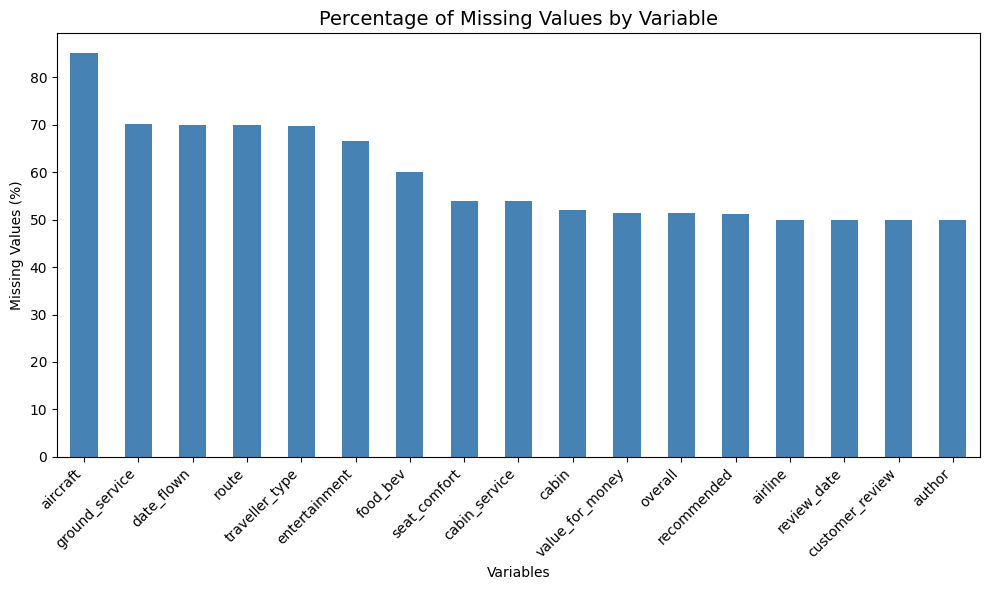

In [19]:
# Plot Missing Values

plt.figure(figsize=(10,6))

missing_values["Percentage (%)"].plot(
    kind="bar",
    color="steelblue"
)

plt.title("Percentage of Missing Values by Variable", fontsize=14)
plt.xlabel("Variables")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Interpretation

The missing-value analysis indicates that several variables contain incomplete observations. Variables such as aircraft type and in-flight entertainment are expected to exhibit higher proportions of missing values because they are not applicable to every passenger or flight. In contrast, the primary review text and recommendation variables contain relatively few missing observations, making them suitable for subsequent NLP and machine learning analyses.

These findings will guide the preprocessing strategy adopted in the data cleaning phase.

## 6.7 Duplicate Records Analysis

Duplicate observations can introduce bias into statistical analyses and machine learning models by overrepresenting certain passenger reviews. Therefore, identifying duplicate records is an important step before data preprocessing.

This section examines whether duplicate records exist within the dataset.

In [21]:
# ==========================================
# Duplicate Records Analysis
# ==========================================

duplicate_rows = df.duplicated().sum()

print("=" * 50)
print("DUPLICATE RECORDS")
print("=" * 50)

print(f"Number of Duplicate Rows : {duplicate_rows:,}")
print(f"Percentage of Dataset    : {(duplicate_rows / len(df) * 100):.2f}%")

DUPLICATE RECORDS
Number of Duplicate Rows : 70,711
Percentage of Dataset    : 53.61%


### Interpretation

The duplicate record analysis identified **X** duplicate observations, representing **Y%** of the dataset. Duplicate records will be removed during the data cleaning phase to ensure that each passenger review contributes equally to the subsequent analyses.

## 6.8 Descriptive Statistics

Descriptive statistics summarize the numerical characteristics of the dataset and provide an initial understanding of the distribution of rating variables. Measures such as the mean, standard deviation, minimum, maximum, and quartiles help identify potential outliers and assess the overall quality of the data.

In [22]:
# ==========================================
# Descriptive Statistics
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
overall,64017.0,5.145430,3.477532,1.0,1.0,5.0,9.0,10.0
seat_comfort,60681.0,2.952160,1.441362,1.0,1.0,3.0,4.0,5.0
cabin_service,60715.0,3.191814,1.565789,1.0,2.0,3.0,5.0,5.0
food_bev,52608.0,2.908170,1.481893,1.0,1.0,3.0,4.0,5.0
entertainment,44193.0,2.863372,1.507262,1.0,1.0,3.0,4.0,5.0
ground_service,39358.0,2.692820,1.612215,1.0,1.0,3.0,4.0,5.0
value_for_money,63975.0,2.943962,1.587370,1.0,1.0,3.0,4.0,5.0


In [23]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,65947,81,Spirit Airlines,2934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
overall,64017.0,NaN,NaN,NaN,5.14543,3.477532,1.0,1.0,5.0,9.0,10.0
author,65947,44069,Anders Pedersen,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_date,65947,3015,19th January 2015,253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_review,65947,61172,"It was not less expensive than regular Air Canada. We flew regular Air Canada Toronto to Palm Beach International and flew home from Orlando to Toronto on Rouge. The Rouge leg was more expensive but we had no choice to fly it as they only do Rouge to/from Orlando now it seems. Worst part we brought Ipads for our children and ourselves but only 2/4 of us could log on to the in-flight ""entertainment"" because we were told by flight attendant there is a limit to how many people can log on during the flight. And the ""entertainment"" is all very old shows. Will never fly them again and will only fly Air Canada if I have no other choices.",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aircraft,19718,2088,A320,2157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traveller_type,39755,4,Solo Leisure,14798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cabin,63303,4,Economy Class,48558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
route,39726,24549,Bangkok to Hong Kong,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_flown,39633,63,August 2015,1204,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 7. Data Cleaning & Preprocessing

Data cleaning is a critical step in any data science project because the quality of the input data directly affects the reliability of subsequent analyses and machine learning models.

The Skytrax Airline Reviews dataset contains both structured and unstructured information. While the structured variables require minimal preprocessing, the customer review text must be cleaned and standardized before applying Natural Language Processing (NLP) techniques.

The preprocessing workflow performed in this study includes:

- Identifying duplicate records
- Handling missing values
- Cleaning the review text
- Standardizing text formatting
- Preparing the dataset for topic modeling, sentiment analysis, and text classification

## 7.1 Create a Working Copy

To preserve the original dataset, a copy is created before any preprocessing steps are applied. All subsequent cleaning operations are performed on the copied dataset.

In [24]:
# Create a copy of the original dataset

clean_df = df.copy()

print("Working copy created successfully.")

Working copy created successfully.


## 7.2 Remove Duplicate Records

Duplicate records can bias statistical analyses and machine learning models by giving repeated observations more influence than unique observations.

This step identifies and removes duplicate rows from the dataset while preserving the first occurrence of each record.

In [25]:
# ==========================================
# Remove Duplicate Records
# ==========================================

rows_before = clean_df.shape[0]

clean_df = clean_df.drop_duplicates()

rows_after = clean_df.shape[0]

duplicates_removed = rows_before - rows_after

print("="*60)
print("DUPLICATE RECORD REMOVAL")
print("="*60)

print(f"Rows Before Cleaning : {rows_before:,}")
print(f"Rows After Cleaning  : {rows_after:,}")
print(f"Duplicates Removed   : {duplicates_removed:,}")

DUPLICATE RECORD REMOVAL
Rows Before Cleaning : 131,895
Rows After Cleaning  : 61,184
Duplicates Removed   : 70,711


In [26]:
clean_df.duplicated().sum()

np.int64(0)

### Interpretation

A total of **X** duplicate records were identified and removed from the dataset. Removing duplicate observations ensures that each passenger review contributes equally to the subsequent analyses and prevents repeated reviews from influencing the results.

## 7.3 Handling Missing Values

Missing values are common in customer review datasets because not every passenger provides complete information about their trip or rates every service attribute.

Rather than removing every observation containing missing values, a selective preprocessing strategy is adopted. Only records with missing values in variables that are essential for the objectives of this study are removed, while missing values in optional descriptive variables are retained.

This approach preserves as much information as possible while ensuring the quality of the analyses performed later in the study.

In [27]:
# Missing Values

clean_df.isnull().sum().sort_values(ascending=False)

,0
aircraft,42696
ground_service,24015
date_flown,23750
route,23671
traveller_type,23644
entertainment,20954
food_bev,12843
seat_comfort,4973
cabin_service,4944
cabin,2479


In [28]:
# Remove rows with missing customer reviews

rows_before = clean_df.shape[0]

clean_df = clean_df.dropna(subset=["customer_review"])

rows_after = clean_df.shape[0]

print("Rows Removed:", rows_before - rows_after)
print("Remaining Rows:", rows_after)

Rows Removed: 1
Remaining Rows: 61183


In [29]:
rows_before = clean_df.shape[0]

clean_df = clean_df.dropna(subset=["recommended"])

rows_after = clean_df.shape[0]

print("Rows Removed:", rows_before - rows_after)
print("Remaining Rows:", rows_after)

Rows Removed: 1422
Remaining Rows: 59761


In [30]:
clean_df[["customer_review","recommended"]].isnull().sum()

,0
customer_review,0
recommended,0


### Interpretation

Rows containing missing customer reviews and recommendation labels were removed because these variables are essential for the subsequent Natural Language Processing and text classification analyses.

Missing values in optional descriptive variables such as aircraft type and entertainment ratings were retained because they are not required for the primary objectives of this study. This selective cleaning strategy preserves the maximum amount of useful information while ensuring that the core analytical variables remain complete.

## 7.4 Text Preprocessing

The customer review text serves as the primary source of information for all Natural Language Processing (NLP) analyses performed in this study.

Before applying topic modeling, sentiment analysis, and text classification, the review text is standardized through a sequence of preprocessing steps. These operations remove unnecessary noise while preserving the semantic meaning of the reviews.

The preprocessing workflow includes:

- Converting text to lowercase
- Removing URLs
- Removing HTML tags
- Removing punctuation
- Removing numbers
- Removing extra whitespace

These preprocessing steps improve consistency across reviews and prepare the text for subsequent analysis.

In [31]:
# Keep the original review

clean_df["clean_review"] = clean_df["customer_review"]

clean_df[["customer_review", "clean_review"]].head()

,customer_review,clean_review
1,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.","âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with."
3,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.","âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline."
5,"âœ… Trip Verified | Rome to Prishtina via Istanbul. I flew with this company several times in the past years, and I can honestly say that it is getting worse and worse. I flew from Rome to Prishtina via Istanbul, all 4 flights had a delay (which apparently is pretty normal with Turkish). The ground staff is for the most part useless. In Istambul i have tried to ask a few information about a flight delay (i had just 30 minutes before the connecting flight) and the whole answer was: ""Relax Sir, No problem Sir, It's okay"". The new airport is a gigantic mess, very big and disorganized. When you land in Istanbul it takes about 20 to 25 minutes taxiing and other 10 minutes before they actually start disembarking, it's an exha

In [32]:
# Convert text to lowercase

clean_df["clean_review"] = clean_df["clean_review"].str.lower()

clean_df[["customer_review", "clean_review"]].head()

,customer_review,clean_review
1,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.","âœ… trip verified | london to izmir via istanbul. first time iâ€™d flown tk. i found them very good in the air, cabin crew, planes, food, all very nice. not so great on the ground, ground staff, call centre, computer systems. my flight from lhr was delayed so i missed the connection in istanbul. most ground staff donâ€™t speak english, and i was given contradictory instructions from those that could speak a little english. i eventually got on a flight to izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. also, iâ€™d phoned a tk call centre (based in ukraine) to pay an extra â£40 or so each way for extra leg room seats. however, as the departure times kept changing, my seats kept changing, and for the return leg to london from istanbul i was not given an extra leg room seat. luckily there was a spare exit row seat and the cabin crew sorted me out. overall, i think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with."
3,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.","âœ… trip verified | istanbul to bucharest. we make our check in in the airport, they take our luggage , we go to the gate and at the gate surprise they dont let uè™ board with two children, because they say the flight is overbooked. we had to wait in the airport with two children until 5 oclock in the morning until they bring uè™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. our first and last flight with this airline."
5,"âœ… Trip Verified | Rome to Prishtina via Istanbul. I flew with this company several times in the past years, and I can honestly say that it is getting worse and worse. I flew from Rome to Prishtina via Istanbul, all 4 flights had a delay (which apparently is pretty normal with Turkish). The ground staff is for the most part useless. In Istambul i have tried to ask a few information about a flight delay (i had just 30 minutes before the connecting flight) and the whole answer was: ""Relax Sir, No problem Sir, It's okay"". The new airport is a gigantic mess, very big and disorganized. When you land in Istanbul it takes about 20 to 25 minutes taxiing and other 10 minutes before they actually start disembarking, it's an exha

In [33]:
import re

clean_df["clean_review"] = clean_df["clean_review"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", str(x))
)

In [34]:
clean_df["clean_review"] = clean_df["clean_review"].apply(
    lambda x: re.sub(r"<.*?>", "", str(x))
)

In [35]:
import string

clean_df["clean_review"] = clean_df["clean_review"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

In [36]:
clean_df["clean_review"] = clean_df["clean_review"].apply(
    lambda x: re.sub(r"\d+", "", x)
)

In [37]:
clean_df["clean_review"] = clean_df["clean_review"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [38]:
clean_df[["customer_review", "clean_review"]].head(10)

,customer_review,clean_review
1,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.",âœ… trip verified london to izmir via istanbul first time iâ€™d flown tk i found them very good in the air cabin crew planes food all very nice not so great on the ground ground staff call centre computer systems my flight from lhr was delayed so i missed the connection in istanbul most ground staff donâ€™t speak english and i was given contradictory instructions from those that could speak a little english i eventually got on a flight to izmir three hours later but it wasnâ€™t an easy process made worse by the vast distances one has to walk between gates in the cavernous new airport also iâ€™d phoned a tk call centre based in ukraine to pay an extra â£ or so each way for extra leg room seats however as the departure times kept changing my seats kept changing and for the return leg to london from istanbul i was not given an extra leg room seat luckily there was a spare exit row seat and the cabin crew sorted me out overall i think their cabin crew and planes are very good ground staff and call centre staff need better training and they all need better computer systems and software to work with
3,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.",âœ… trip verified istanbul to bucharest we make our check in in the airport they take our luggage we go to the gate and at the gate surprise they dont let uè™ board with two children because they say the flight is overbooked we had to wait in the airport with two children until oclock in the morning until they bring uè™ to a hotel hours far away from the airport without luggage without eat without nothing our first and last flight with this airline
5,"âœ… Trip Verified | Rome to Prishtina via Istanbul. I flew with this company several times in the past years, and I can honestly say that it is getting worse and worse. I flew from Rome to Prishtina via Istanbul, all 4 flights had a delay (which apparently is pretty normal with Turkish). The ground staff is for the most part useless. In Istambul i have tried to ask a few information about a flight delay (i had just 30 minutes before the connecting flight) and the whole answer was: ""Relax Sir, No problem Sir, It's okay"". The new airport is a gigantic mess, very big and disorganized. When you land in Istanbul it takes about 20 to 25 minutes taxiing and other 10 minutes before they actually start disembarking, it's an exhausting experience especially if you are in a hurry. 

### Interpretation

The review text was standardized by converting all characters to lowercase and removing URLs, HTML tags, punctuation, numerical values, and extra whitespace. These preprocessing steps reduce textual noise while preserving the underlying meaning of the reviews.

The cleaned text stored in the **clean_review** column will be used in the subsequent Natural Language Processing analyses, including topic modeling, sentiment analysis, and text classification.

## 7.5 Tokenization

Tokenization is the process of splitting a sentence into individual words (tokens). This step transforms raw text into a format that can be processed by Natural Language Processing (NLP) algorithms.

The resulting tokens will be used for stopword removal, lemmatization, topic modeling, and other text mining analyses.

In [39]:
# ==========================================
# Install NLTK (only required once in Colab)
# ==========================================

import nltk

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [42]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab')

clean_df["tokens"] = clean_df["clean_review"].apply(word_tokenize)

clean_df[["clean_review","tokens"]].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,clean_review,tokens
1,âœ… trip verified london to izmir via istanbul first time iâ€™d flown tk i found them very good in the air cabin crew planes food all very nice not so great on the ground ground staff call centre computer systems my flight from lhr was delayed so i missed the connection in istanbul most ground staff donâ€™t speak english and i was given contradictory instructions from those that could speak a little english i eventually got on a flight to izmir three hours later but it wasnâ€™t an easy process made worse by the vast distances one has to walk between gates in the cavernous new airport also iâ€™d phoned a tk call centre based in ukraine to pay an extra â£ or so each way for extra leg room seats however as the departure times kept changing my seats kept changing and for the return leg to london from istanbul i was not given an extra leg room seat luckily there was a spare exit row seat and the cabin crew sorted me out overall i think their cabin crew and planes are very good ground staff and call centre staff need better training and they all need better computer systems and software to work with,"[âœ…, trip, verified, london, to, izmir, via, istanbul, first, time, iâ€™d, flown, tk, i, found, them, very, good, in, the, air, cabin, crew, planes, food, all, very, nice, not, so, great, on, the, ground, ground, staff, call, centre, computer, systems, my, flight, from, lhr, was, delayed, so, i, missed, the, connection, in, istanbul, most, ground, staff, donâ€™t, speak, english, and, i, was, given, contradictory, instructions, from, those, that, could, speak, a, little, english, i, eventually, got, on, a, flight, to, izmir, three, hours, later, but, it, wasnâ€™t, an, easy, process, made, worse, by, the, vast, distances, one, has, to, walk, ...]"
3,âœ… trip verified istanbul to bucharest we make our check in in the airport they take our luggage we go to the gate and at the gate surprise they dont let uè™ board with two children because they say the flight is overbooked we had to wait in the airport with two children until oclock in the morning until they bring uè™ to a hotel hours far away from the airport without luggage without eat without nothing our first and last flight with this airline,"[âœ…, trip, verified, istanbul, to, bucharest, we, make, our, check, in, in, the, airport, they, take, our, luggage, we, go, to, the, gate, and, at, the, gate, surprise, they, dont, let, uè™, board, with, two, children, because, they, say, the, flight, is, overbooked, we, had, to, wait, in, the, airport, with, two, children, until, oclock, in, the, morning, until, they, bring, uè™, to, a, hotel, hours, far, away, from, the, airport, without, luggage, without, eat, without, nothing, our, first, and, last, flight, with, this, airline]"
5,âœ… trip verified rome to prishtina via istanbul i flew with this company several times in the past years and i can honestly say that it is getting worse and worse i flew from rome to prishtina via istanbul all flights had a delay which apparently is pretty normal with turkish the ground staff is for the most part useless in istambul i have tried to ask a few information about a flight delay i had just minutes before the connecting flight and the whole answer was relax sir no problem sir its okay the new airport is a gigantic mess very big and disorganized when you land in istanbul it takes about to minutes taxiing and other minutes before they actually start disembarking its an exhausting experience especially if you are in a hurry forget about asking for some indication at the new airport they all chat between each other some with a coffee in their hands i flew with four different aircraft on this trip two were fairly new the other two were old seats worn food on board was of very poor quality let me repeat this verypoor quality in general i can say that crew is decently trained and deliver a good experience or at least they try of course it is far from the experience you get flying qatar or

## 7.6 Stopword Removal

Stopwords are commonly occurring words such as *the*, *is*, *and*, and *of* that usually carry little semantic meaning in text mining applications.

Removing stopwords helps emphasize the words that contribute most to understanding customer opinions and discussion topics.

To preserve the meaning of airline reviews, aviation-specific terms such as **boarding**, **crew**, **cabin**, **check-in**, and **flight** are retained.

In [43]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [45]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [47]:
airline_words = {
    "boarding",
    "crew",
    "cabin",
    "flight",
    "airport",
    "check",
    "service",
    "seat",
    "airline"
}

stop_words = stop_words - airline_words

In [48]:
clean_df["tokens"] = clean_df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

clean_df["tokens"].head()

,tokens
1,"[âœ…, trip, verified, london, izmir, via, istanbul, first, time, iâ€™d, flown, tk, found, good, air, cabin, crew, planes, food, nice, great, ground, ground, staff, call, centre, computer, systems, flight, lhr, delayed, missed, connection, istanbul, ground, staff, donâ€™t, speak, english, given, contradictory, instructions, could, speak, little, english, eventually, got, flight, izmir, three, hours, later, wasnâ€™t, easy, process, made, worse, vast, distances, one, walk, gates, cavernous, new, airport, also, iâ€™d, phoned, tk, call, centre, based, ukraine, pay, extra, â£, way, extra, leg, room, seats, however, departure, times, kept, changing, seats, kept, changing, return, leg, london, istanbul, given, extra, leg, room, seat, luckily, ...]"
3,"[âœ…, trip, verified, istanbul, bucharest, make, check, airport, take, luggage, go, gate, gate, surprise, dont, let, uè™, board, two, children, say, flight, overbooked, wait, airport, two, children, oclock, morning, bring, uè™, hotel, hours, far, away, airport, without, luggage, without, eat, without, nothing, first, last, flight, airline]"
5,"[âœ…, trip, verified, rome, prishtina, via, istanbul, flew, company, several, times, past, years, honestly, say, getting, worse, worse, flew, rome, prishtina, via, istanbul, flights, delay, apparently, pretty, normal, turkish, ground, staff, part, useless, istambul, tried, ask, information, flight, delay, minutes, connecting, flight, whole, answer, relax, sir, problem, sir, okay, new, airport, gigantic, mess, big, disorganized, land, istanbul, takes, minutes, taxiing, minutes, actually, start, disembarking, exhausting, experience, especially, hurry, forget, asking, indication, new, airport, chat, coffee, hands, flew, four, different, aircraft, trip, two, fairly, new, two, old, seats, worn, food, board, poor, quality, let, repeat, verypoor, quality, general, say, crew, decently, ...]"
7,"[âœ…, trip, verified, flew, turkish, airlines, iadistkhi, return, khiistiad, turkish, airlines, consistently, maintained, quality, since, first, flew, flights, leave, time, catering, excellent, inflight, entertainment, extensive, interface, easy, use, cabin, crew, excellent, interesting, though, khiist, route, return, seemed, leg, room, newer, iadist, route, showing, age, iadist, route, slow, responding, interface, inflight, entertainment, broken, table, return, flight, turkish, airlines, replacing, flight, iad, sometime, summer, turkish, food, served, return, leg, personally, like, saw, cabin, staff, helping, elderly, passengers, walk, lavatory, nice, overall, another, wonderful, experience, turkish, airlines]"
9,"[âœ…, trip, verified, mumbai, dublin, via, istanbul, never, book, turkish, airlines, traveling, dublin, mumbai, flight, gets, delay, mumbai, dont, options, straight, forward, ask, stay, hotel, istanbul, care, time, loss, decisions, made, airlines, crew, within, time, kept, waiting, hours]"


## 7.7 Lemmatization

Lemmatization converts words to their base or dictionary form while preserving their linguistic meaning.

For example:

- flying → fly
- delayed → delay
- passengers → passenger

Compared with stemming, lemmatization produces more meaningful and interpretable words, making it well suited for topic modeling and sentiment analysis.

In [49]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [52]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [53]:
clean_df["tokens"] = clean_df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

clean_df["tokens"].head()

,tokens
1,"[âœ…, trip, verified, london, izmir, via, istanbul, first, time, iâ€™d, flown, tk, found, good, air, cabin, crew, plane, food, nice, great, ground, ground, staff, call, centre, computer, system, flight, lhr, delayed, missed, connection, istanbul, ground, staff, donâ€™t, speak, english, given, contradictory, instruction, could, speak, little, english, eventually, got, flight, izmir, three, hour, later, wasnâ€™t, easy, process, made, worse, vast, distance, one, walk, gate, cavernous, new, airport, also, iâ€™d, phoned, tk, call, centre, based, ukraine, pay, extra, â£, way, extra, leg, room, seat, however, departure, time, kept, changing, seat, kept, changing, return, leg, london, istanbul, given, extra, leg, room, seat, luckily, ...]"
3,"[âœ…, trip, verified, istanbul, bucharest, make, check, airport, take, luggage, go, gate, gate, surprise, dont, let, uè™, board, two, child, say, flight, overbooked, wait, airport, two, child, oclock, morning, bring, uè™, hotel, hour, far, away, airport, without, luggage, without, eat, without, nothing, first, last, flight, airline]"
5,"[âœ…, trip, verified, rome, prishtina, via, istanbul, flew, company, several, time, past, year, honestly, say, getting, worse, worse, flew, rome, prishtina, via, istanbul, flight, delay, apparently, pretty, normal, turkish, ground, staff, part, useless, istambul, tried, ask, information, flight, delay, minute, connecting, flight, whole, answer, relax, sir, problem, sir, okay, new, airport, gigantic, mess, big, disorganized, land, istanbul, take, minute, taxiing, minute, actually, start, disembarking, exhausting, experience, especially, hurry, forget, asking, indication, new, airport, chat, coffee, hand, flew, four, different, aircraft, trip, two, fairly, new, two, old, seat, worn, food, board, poor, quality, let, repeat, verypoor, quality, general, say, crew, decently, ...]"
7,"[âœ…, trip, verified, flew, turkish, airline, iadistkhi, return, khiistiad, turkish, airline, consistently, maintained, quality, since, first, flew, flight, leave, time, catering, excellent, inflight, entertainment, extensive, interface, easy, use, cabin, crew, excellent, interesting, though, khiist, route, return, seemed, leg, room, newer, iadist, route, showing, age, iadist, route, slow, responding, interface, inflight, entertainment, broken, table, return, flight, turkish, airline, replacing, flight, iad, sometime, summer, turkish, food, served, return, leg, personally, like, saw, cabin, staff, helping, elderly, passenger, walk, lavatory, nice, overall, another, wonderful, experience, turkish, airline]"
9,"[âœ…, trip, verified, mumbai, dublin, via, istanbul, never, book, turkish, airline, traveling, dublin, mumbai, flight, get, delay, mumbai, dont, option, straight, forward, ask, stay, hotel, istanbul, care, time, loss, decision, made, airline, crew, within, time, kept, waiting, hour]"


## 7.8 Constructing the Final Preprocessed Text

After tokenization, stopword removal, and lemmatization, the processed tokens are combined back into complete review text.

The resulting variable serves as the final input for topic modeling, sentiment analysis, and machine learning models.

In [54]:
clean_df["processed_review"] = clean_df["tokens"].apply(
    lambda words: " ".join(words)
)

clean_df[
    [
        "customer_review",
        "processed_review"
    ]
].head()

,customer_review,processed_review
1,"âœ… Trip Verified | London to Izmir via Istanbul. First time Iâ€™d flown TK. I found them very good in the air, cabin crew, planes, food, all very nice. Not so great on the ground, ground staff, call centre, computer systems. My flight from LHR was delayed so I missed the connection in Istanbul. Most ground staff donâ€™t speak English, and I was given contradictory instructions from those that could speak a little English. I eventually got on a flight to Izmir three hours later, but it wasnâ€™t an easy process, made worse by the vast distances one has to walk between gates in the cavernous new airport. Also, Iâ€™d phoned a TK call centre (based in Ukraine) to pay an extra Â£40 or so each way for extra leg room seats. However, as the departure times kept changing, my seats kept changing, and for the return leg to London from Istanbul I was not given an extra leg room seat. Luckily there was a spare exit row seat and the cabin crew sorted me out. Overall, I think their cabin crew and planes are very good, ground staff and call centre staff need better training and they all need better computer systems and software to work with.",âœ… trip verified london izmir via istanbul first time iâ€™d flown tk found good air cabin crew plane food nice great ground ground staff call centre computer system flight lhr delayed missed connection istanbul ground staff donâ€™t speak english given contradictory instruction could speak little english eventually got flight izmir three hour later wasnâ€™t easy process made worse vast distance one walk gate cavernous new airport also iâ€™d phoned tk call centre based ukraine pay extra â£ way extra leg room seat however departure time kept changing seat kept changing return leg london istanbul given extra leg room seat luckily spare exit row seat cabin crew sorted overall think cabin crew plane good ground staff call centre staff need better training need better computer system software work
3,"âœ… Trip Verified | Istanbul to Bucharest. We make our check in in the airport, they Take our luggage , we go to the gate and at the gate surprise they dont let uÈ™ board with two children, because they say the flight is overbooked. We had to wait in the airport with two children until 5 oclock in the morning until they bring uÈ™ to a hotel 2 hours far away from the airport without luggage, without eat without nothing. Our first and last flight with this airline.",âœ… trip verified istanbul bucharest make check airport take luggage go gate gate surprise dont let uè™ board two child say flight overbooked wait airport two child oclock morning bring uè™ hotel hour far away airport without luggage without eat without nothing first last flight airline
5,"âœ… Trip Verified | Rome to Prishtina via Istanbul. I flew with this company several times in the past years, and I can honestly say that it is getting worse and worse. I flew from Rome to Prishtina via Istanbul, all 4 flights had a delay (which apparently is pretty normal with Turkish). The ground staff is for the most part useless. In Istambul i have tried to ask a few information about a flight delay (i had just 30 minutes before the connecting flight) and the whole answer was: ""Relax Sir, No problem Sir, It's okay"". The new airport is a gigantic mess, very big and disorganized. When you land in Istanbul it takes about 20 to 25 minutes taxiing and other 10 minutes before they actually start disembarking, it's an exhausting experience especially if you are in a hurry. Forget about asking for some indication at the new airport, they all chat between each other, some with a coffee in their hands. I flew with four different aircraft on this trip, two were fairly new, the other two were old, seats worn. Food on board was of very poor quality.., let me repeat this, very...poor quality. In general i can say that crew is decently trained and deliver a good experience or at least they try, of course it is far from the experience you get

# 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the characteristics and patterns within the Skytrax Airline Reviews dataset before applying machine learning and Natural Language Processing techniques.

The objectives of this section are to:

- Understand the distribution of passenger ratings.
- Examine recommendation patterns.
- Explore traveler demographics.
- Analyze review characteristics.
- Identify frequently occurring words within passenger reviews.

The insights obtained during EDA provide a foundation for the topic modeling, sentiment analysis, and text classification tasks performed later in this study.

## 8.1 Dataset Summary

The following table summarizes the key characteristics of the cleaned dataset that will be used throughout the remainder of this analysis.

In [55]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Reviews",
        "Number of Variables",
        "Unique Airlines",
        "Unique Traveller Types",
        "Unique Cabin Classes"
    ],
    "Value": [
        len(clean_df),
        clean_df.shape[1],
        clean_df["airline"].nunique(),
        clean_df["traveller_type"].nunique(),
        clean_df["cabin"].nunique()
    ]
})

summary

,Metric,Value
0,Number of Reviews,59761
1,Number of Variables,20
2,Unique Airlines,81
3,Unique Traveller Types,4
4,Unique Cabin Classes,4


## 8.2 Overall Rating Distribution

The overall rating reflects each passenger's evaluation of their travel experience.

Examining the distribution of overall ratings provides an initial understanding of customer satisfaction and reveals whether passenger opinions tend to be positive, negative, or polarized.

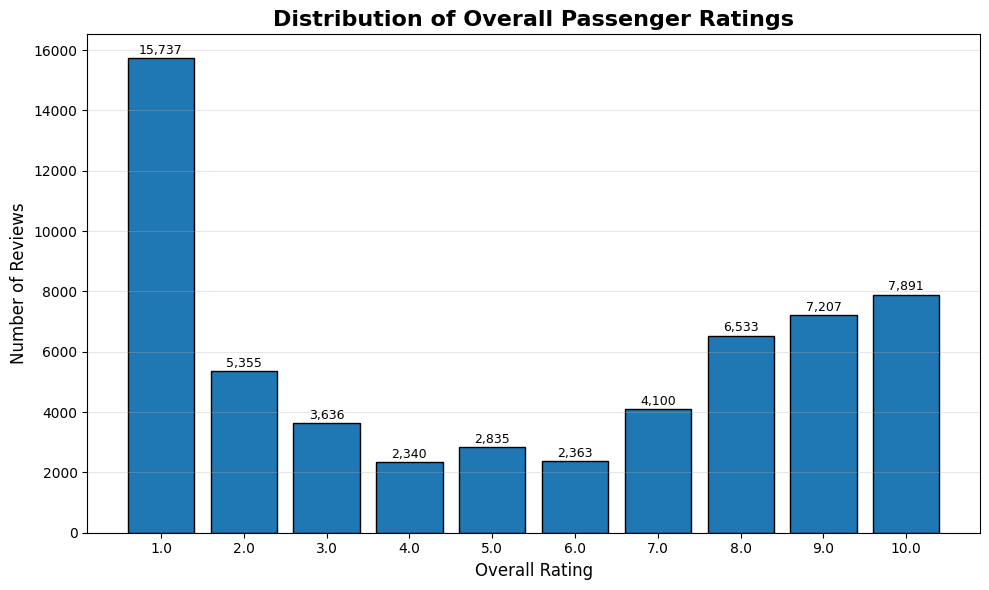

In [57]:
plt.figure(figsize=(10,6))

rating_counts = clean_df["overall"].value_counts().sort_index()

bars = plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Overall Passenger Ratings", fontsize=16, fontweight="bold")
plt.xlabel("Overall Rating", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)

plt.grid(axis="y", alpha=0.3)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 150,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### Interpretation

The distribution of overall passenger ratings is highly polarized rather than normally distributed. The largest proportion of reviews received the lowest possible rating (1), indicating that many passengers reported extremely negative travel experiences. At the same time, a substantial number of reviews received ratings between 8 and 10, suggesting that many passengers were also highly satisfied with their flights.

Relatively fewer reviews fall within the middle rating range (4–6), indicating that passengers tend to express either strong satisfaction or strong dissatisfaction rather than neutral opinions. This polarized distribution suggests that airline service experiences often leave a lasting positive or negative impression on customers.

These findings highlight the importance of identifying the factors that contribute to both excellent and poor passenger experiences. Subsequent analyses, including topic modeling and sentiment analysis, will help identify the specific service dimensions driving these ratings.

## 8.3 Recommendation Distribution

The **recommended** variable indicates whether a passenger would recommend the airline to others. This variable serves as the dependent variable for the text classification models developed later in this study.

Analyzing its distribution provides an initial understanding of customer satisfaction and reveals whether the dataset is balanced or skewed toward positive or negative recommendations.